In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

FOLDS = 5

In [ ]:
def show_plots(directory):
    perfs = []
    hypers = pd.read_csv(f"{directory}/hyperparameters.txt")
    hypers.set_index("Fold", inplace=True)
    for k in range(FOLDS):
        perf = pd.read_csv(f"{directory}/fold_{k}.txt")
        #perf = perf.iloc[1:]
        perfs.append(perf)

        title = " ".join([f"{name}: {hypers.at[k, name]}" for name in hypers.columns])

        fig = plt.figure(figsize=(18, 5))
        fig.suptitle(title)
        loss = plt.subplot(1, 2, 1)
        loss.plot(perf['Iteration'].iloc[10:], perf['Loss'].iloc[10:])
        loss.set_ylabel("loss")
        loss.set_xlabel("iterations")

        #fig = plt.figure(figsize=(9, 5))
        acc = plt.subplot(1, 2, 2)
        lines = acc.plot(perf['Iteration'], perf['Train_acc'], perf['Iteration'], perf['Test_acc'])
        acc.set_ylabel("Accuracy")
        acc.set_xlabel("iterations")
        #acc.set_xticks()
        acc.legend(lines, ['Train', 'Test'])
        #acc.set_xticks(loss.get_xticks, rotation=20)

        plt.show(fig)
        plt.close(fig)
        #return perfs

In [ ]:
# linear logistic regression
show_plots("linear_lr")

In [ ]:
# linear SVM
show_plots("linear_svm")

In [ ]:
# kernel linear logistic regression
show_plots("kernel_linear_lr")

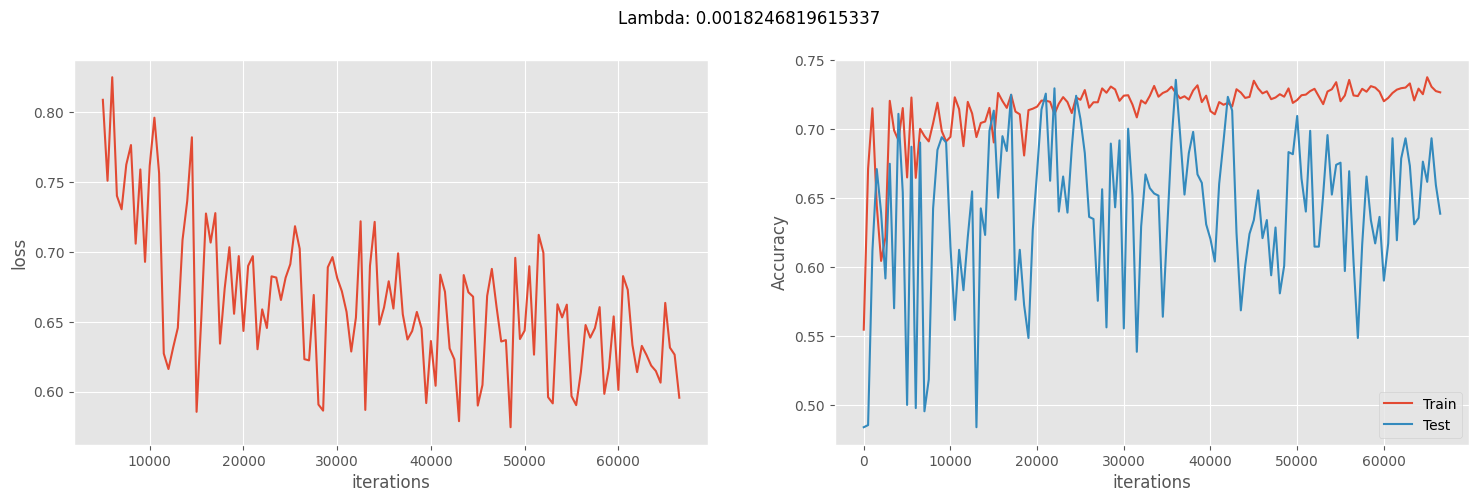

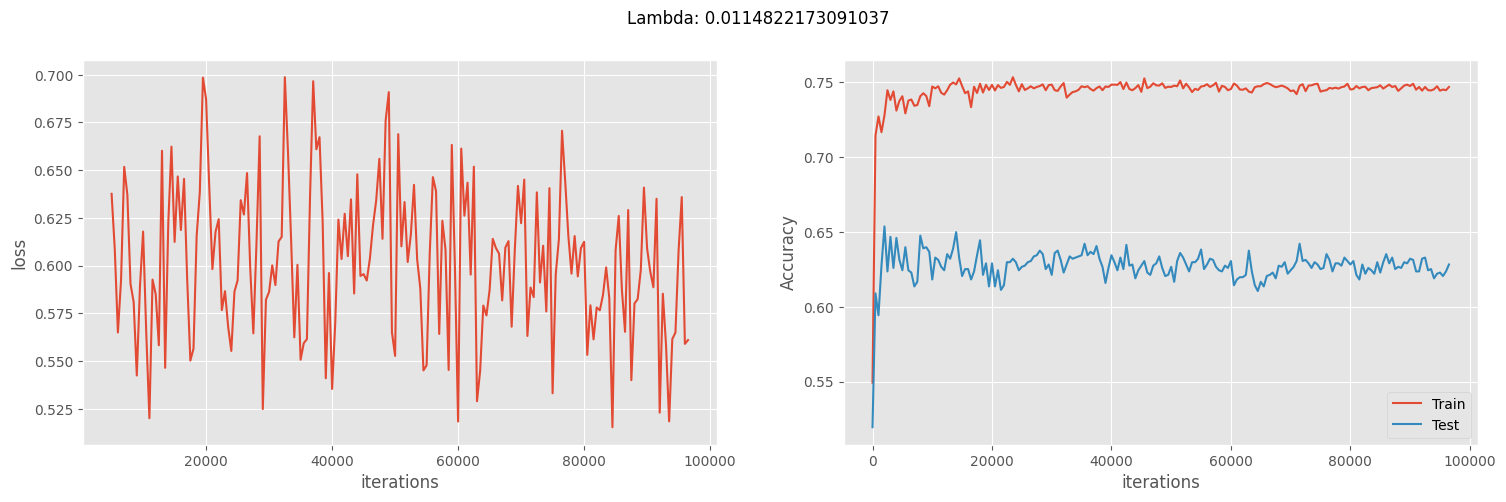

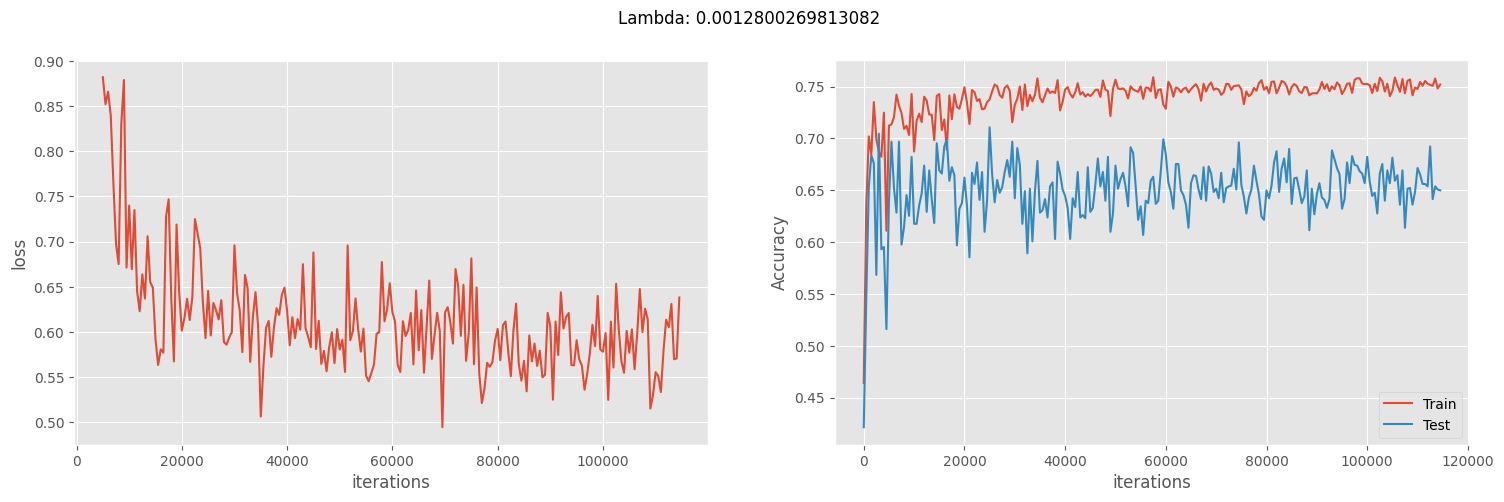

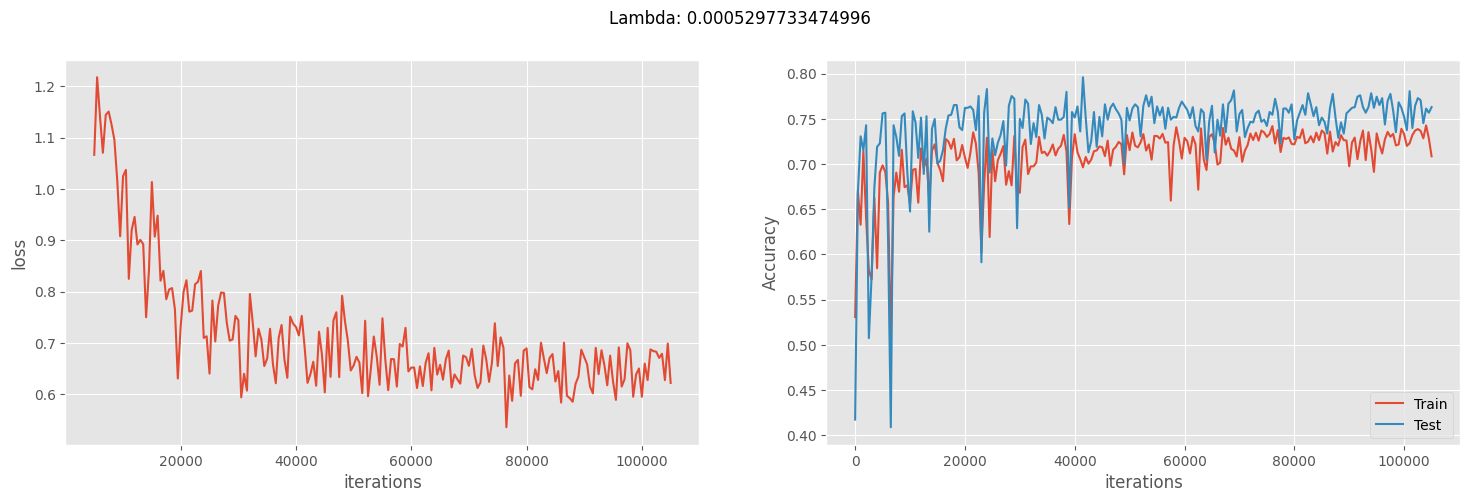

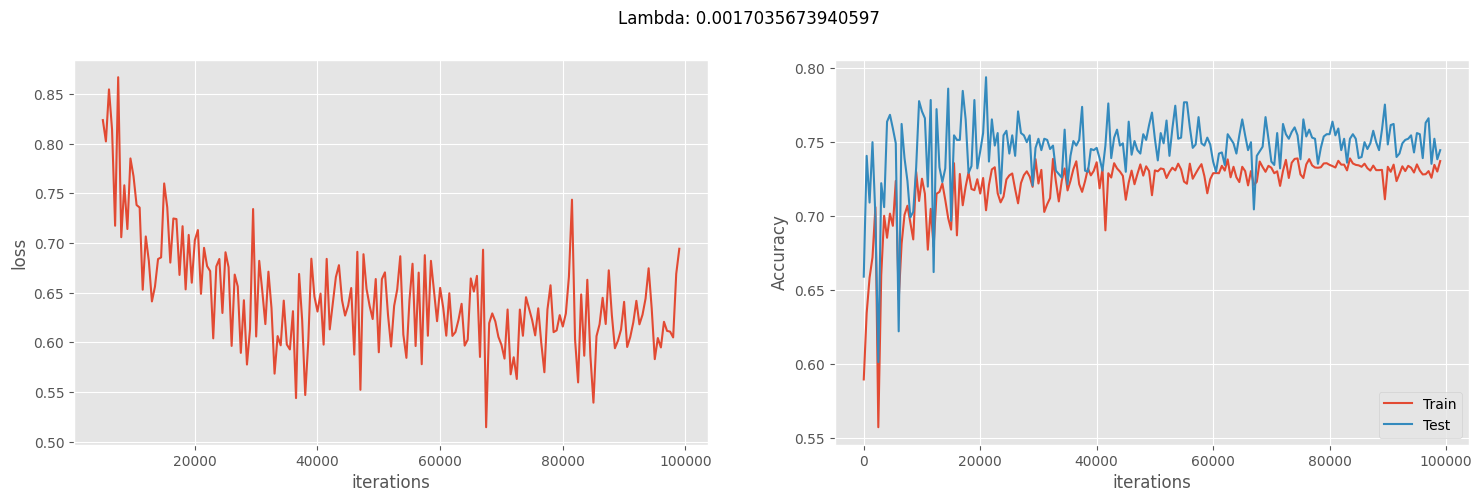

In [136]:
# kernel linear SVM
show_plots("kernel_linear_svm")

In [ ]:
# kernel gaussian logistic regression
show_plots("kernel_rbf_lr")

In [ ]:
# kernel gaussian SVM
show_plots("kernel_rbf_svm")

In [ ]:
# kernel polynomial logistic regression
show_plots("kernel_poly_lr")

In [ ]:
# kernel polynomial SVM
show_plots("kernel_poly_svm")